# Zadanie 2: Tureckie Crowdfundingowe Startupy – SVM z metodami balansowania

Cel: Przewidywanie sukcesu startupu (`basari_durumu`: başarılı / başarısız).  

Metody balansowania:
- Bez balansowania (baseline)
- class_weight='balanced' w SVM
- Over-sampling: RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
- Under-sampling: RandomUnderSampler, ClusterCentroids, NearMiss (v1,v2,v3), TomekLinks
- Kombinacja: SMOTEENN, SMOTETomek


## Import bibliotek

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Over-sampling
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
    
# Under-sampling
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, NearMiss, TomekLinks

# Kombinacja
from imblearn.combine import SMOTEENN, SMOTETomek

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Wczytanie i eksploracja danych

In [217]:
df = pd.read_csv('startup.csv', encoding='utf-8')
print('Wymiary zbioru:', df.shape)
df.head()

startup_test = pd.read_csv('startup_test.csv')
print('Wymiary zbioru_testowego:', startup_test.shape)

df.head()

Wymiary zbioru: (1328, 35)
Wymiary zbioru_testowego: (300, 34)


,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,konum,bolge,yil,proje_baslama_tarihi,proje_bitis_tarihi,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,yorumlar,destekci_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,basari_durumu
0,fongogo,ödül,diğer,ya hep ya hiç,YardımaTik,Atik Topluluğu,kadın,0,0,2,0,istanbul,marmara,2020,10.06.2020,9.08.2020,60,var,26,0,0,0,0,0,5,1,yok,var,3,32,0,142,Çevremizde yardıma ihtiyacı olan vatandaşlarım...,2500,başarısız
1,fonbulucu,ödül,eğitim,ya hep ya hiç,Bartme - Hayalime Ortak Ol İşbirliği Projesi,Öykü Sorgun,kadın,0,0,1,0,genel,genel,2019,NaN,NaN,60,yok,0,2,0,0,0,0,4,2,yok,yok,0,0,0,161,"Kişiler arası bir takas platformu olan Bartme,...",1500,başarısız
2,fongogo,ödül,dans-performans,hepsi kalsın,KABİLE Sirk Sanatları Şapkasını Açıyor,KABİLE Sirk ve Sahne Sanatları,belirsiz,0,0,1,0,istanbul,marmara,2020,28.12.2020,2.02.2021,36,var,36,19,3,1,0,92,9,1,yok,var,2,3214,0,400,Türkiye'nin ilk çağdaş sirk sanatları topluluğ...,80000,başarısız
3,fongogo,ödül,teknoloji,ya hep ya hiç,Pozitif Basınç Tozsuz Oda,SERHAT KILIÇ,erkek,0,0,1,0,istanbul,marmara,2018,30.10.2018,29.11.2018,30,var,49,5,0,0,0,0,5,1,yok,var,1,1829,5,364,"Geri dönüştürülen kırık telefon ekranlarının, ...",14500,başarısız
4,fongogo,ödül,eğitim,ya hep ya hiç,Mekan314,Okan Kuzer,erkek,0,0,1,0,istanbul,marmara,2014,13.03.2014,12.04.2014,30,var,110,16,0,0,0,17,5,4,var,yok,0,0,0,541,Alternatif sanat dallarını barındıracak yeni b...,1000,başarılı


In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   platform_adi           1328 non-null   str  
 1   kitle_fonlamasi_turu   1328 non-null   str  
 2   kategori               1328 non-null   str  
 3   fon_sekli              1328 non-null   str  
 4   proje_adi              1328 non-null   str  
 5   proje_sahibi           1328 non-null   str  
 6   proje_sahibi_cinsiyet  1328 non-null   str  
 7   kac_proje_destekledi   1328 non-null   int64
 8   kac_projeye_abone      1328 non-null   int64
 9   kac_projenin_sahibi    1328 non-null   int64
 10  kac_proje_takiminda    1328 non-null   int64
 11  konum                  1328 non-null   str  
 12  bolge                  1328 non-null   str  
 13  yil                    1328 non-null   int64
 14  proje_baslama_tarihi   835 non-null    str  
 15  proje_bitis_tarihi     887 non-null    str  
 16 

In [219]:
df.describe(include='all')

,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,konum,bolge,yil,proje_baslama_tarihi,proje_bitis_tarihi,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,yorumlar,destekci_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,basari_durumu
count,1328,1328,1328,1328,1328,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000,1328,1328,1328.000000,835,887,1328.000000,1328,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000,1328,1.328000e+03,1328
unique,6,2,17,2,1314,1260,3,NaN,NaN,NaN,NaN,65,9,NaN,543,660,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,1314,NaN,2
top,fongogo,ödül,film-video-fotoğraf,ya hep ya hiç,Datça Tiyatro Festivali,Canberk Sağnak,erkek,NaN,NaN,NaN,NaN,istanbul,marmara,NaN,11.03.2020,3.09.2019,NaN,var,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yok,var,NaN,NaN,NaN,NaN,Tüm güzellik hizmeti veren işletmeler gibi zor...,NaN,başarısız
freq,887,1319,314,1233,2,5,927,NaN,NaN,NaN,NaN,450,523,NaN,10,5,NaN,776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,989,689,NaN,NaN,NaN,NaN,6,NaN,1015
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.405873,0.000753,1.143072,0.057982,NaN,NaN,2018.024096,NaN,NaN,52.028614,NaN,67.533886,5.085843,0.158886,0.504518,1.095633,24.189006,6.027861,1.823042,NaN,NaN,1.061747,2291.859940,1.368976,352.221386,NaN,3.158216e+04,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.094280,0.027441,0.646605,0.258299,NaN,NaN,2.046783,NaN,NaN,15.224443,NaN,110.131279,8.091983,0.956269,2.521643,7.532540,85.389914,2.255024,1.830293,NaN,NaN,1.241379,14592.603047,2.132958,288.239441,NaN,6.986196e+04,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,2011.000000,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,2017.000000,NaN,NaN,45.000000,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,135.000000,NaN,6.000000e+03,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,2019.000000,NaN,NaN,60.000000,NaN,47.000000,3.000000,0.000000,0.000000,0.000000,3.000000,6.000000,1.000000,NaN,NaN,1.000000,7.000000,0.000000,276.500000,NaN,1.500000e+04,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,2020.000000,NaN,NaN,60.000000,NaN,97.000000,7.000000,0.000000,0.000000,0.000000,18.000000,8.000000,2.000000,NaN,NaN,2.000000,495.750000,4.000000,467.000000,NaN,3.256250e+04,NaN


Rozkład zmiennej docelowej:
basari_durumu
başarısız    1015
başarılı      313
Name: count, dtype: int64

Procent sukcesów: 23.57%


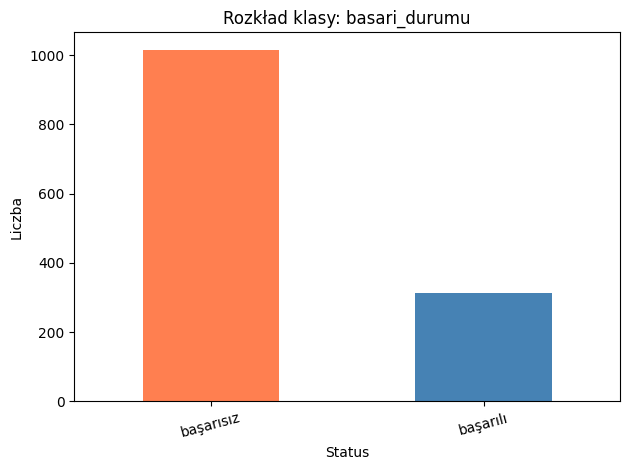

In [220]:
TARGET = 'basari_durumu'
print('Rozkład zmiennej docelowej:')
print(df[TARGET].value_counts())
print(f'\nProcent sukcesów: {(df[TARGET]=="başarılı").mean()*100:.2f}%')

df[TARGET].value_counts().plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Rozkład klasy: basari_durumu')
plt.xlabel('Status')
plt.ylabel('Liczba')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [221]:
print('Brakujące wartości:')
missing = df.isnull().sum()
print(missing[missing > 0])

Brakujące wartości:
proje_baslama_tarihi    493
proje_bitis_tarihi      441
dtype: int64


In [222]:
print('Brakujące wartości testowego:')
missing_startup = startup_test.isnull().sum()
print(missing_startup[missing_startup > 0])

Brakujące wartości testowego:
bolge                     1
proje_baslama_tarihi    118
proje_bitis_tarihi      112
dtype: int64


## Przygotowanie danych

Usuwamy kolumny tekstowe o wysokiej kardynalności i daty, kodujemy kategoryczne.

In [223]:
df_proc = df.copy()

# Kodowanie zmiennej docelowej
df_proc[TARGET] = (df_proc[TARGET] == 'başarılı').astype(int)
print('Kodowanie target: başarılı=1, başarısız=0')
print(df_proc[TARGET].value_counts())

Kodowanie target: başarılı=1, başarısız=0
basari_durumu
0    1015
1     313
Name: count, dtype: int64


In [224]:
# Kolumny do usunięcia
DROP_COLS = [
    'proje_adi',          # Nazwa projektu, unikalne
    'proje_sahibi',       # Imię właściciela, unikalne
    'konum',              # Lokalizacja, duża kardynalność
    'proje_aciklamasi',   # Opis projektu, tekst wolny
    'proje_baslama_tarihi',  # Daty
    'proje_bitis_tarihi',
]

existing_drop = [c for c in DROP_COLS if c in df_proc.columns]
df_proc = df_proc.drop(columns=existing_drop)
print(f'Usunięto kolumny: {existing_drop}')

Usunięto kolumny: ['proje_adi', 'proje_sahibi', 'konum', 'proje_aciklamasi', 'proje_baslama_tarihi', 'proje_bitis_tarihi']


In [225]:
startup_proc = startup_test.copy()

existing_drop_startup = [c for c in DROP_COLS if c in startup_proc.columns]
startup_proc = startup_proc.drop(columns=existing_drop_startup)
print(f'Usunięto kolumny w zbiorze testowym: {existing_drop_startup}')

Usunięto kolumny w zbiorze testowym: ['proje_adi', 'proje_sahibi', 'konum', 'proje_aciklamasi', 'proje_baslama_tarihi', 'proje_bitis_tarihi']


In [226]:
# Typy kolumn
cat_cols = [
    'platform_adi', 'kitle_fonlamasi_turu', 'kategori', 'fon_sekli', 
    'proje_sahibi_cinsiyet', 'bolge', 'tanitim_videosu', 'sss', 
    'web_sitesi', 'sosyal_medya'
]

num_cols = [
    'kac_proje_destekledi', 'kac_projeye_abone', 'kac_projenin_sahibi', 
    'kac_proje_takiminda', 'yil', 'gun_sayisi', 'video_uzunlugu', 
    'gorsel_sayisi', 'guncellemeler', 'yorumlar', 'destekci_sayisi', 
    'odul_sayisi', 'ekip_kisi_sayisi', 'sm_sayisi', 'sm_takipci', 
    'etiket_sayisi', 'icerik_kelime_sayisi', 'hedef_miktari'
]

cat_cols = [c for c in cat_cols if c in df_proc.columns]
num_cols = [c for c in num_cols if c in df_proc.columns]

print(f'Kolumny kategoryczne ({len(cat_cols)}): {cat_cols}')
print(f'Kolumny numeryczne ({len(num_cols)}): {num_cols}')

Kolumny kategoryczne (10): ['platform_adi', 'kitle_fonlamasi_turu', 'kategori', 'fon_sekli', 'proje_sahibi_cinsiyet', 'bolge', 'tanitim_videosu', 'sss', 'web_sitesi', 'sosyal_medya']
Kolumny numeryczne (18): ['kac_proje_destekledi', 'kac_projeye_abone', 'kac_projenin_sahibi', 'kac_proje_takiminda', 'yil', 'gun_sayisi', 'video_uzunlugu', 'gorsel_sayisi', 'guncellemeler', 'yorumlar', 'destekci_sayisi', 'odul_sayisi', 'ekip_kisi_sayisi', 'sm_sayisi', 'sm_takipci', 'etiket_sayisi', 'icerik_kelime_sayisi', 'hedef_miktari']


In [227]:
# Uzupełnianie braków
for col in num_cols:
    if df_proc[col].isnull().sum() > 0:
        median_val = df_proc[col].median()
        df_proc[col] = df_proc[col].fillna(median_val)

for col in cat_cols:
    if df_proc[col].isnull().sum() > 0:
        mode_val = df_proc[col].mode()[0]
        df_proc[col] = df_proc[col].fillna(mode_val)

print(f'Brakujące wartości po uzupełnieniu: {df_proc.isnull().sum().sum()}')

Brakujące wartości po uzupełnieniu: 0


In [228]:
# Uzupełnianie braków w zbiorze testowym
for col in num_cols:
    if startup_proc[col].isnull().sum() > 0:
        median_val_startup = startup_proc[col].median()
        startup_proc[col] = startup_proc[col].fillna(median_val_startup)

for col in cat_cols:
    if startup_proc[col].isnull().sum() > 0:
        mode_val_startup = startup_proc[col].mode()[0]
        startup_proc[col] = startup_proc[col].fillna(mode_val_startup)
        
print(f'Brakujące wartości po uzupełnieniu: {startup_proc.isnull().sum().sum()}')

Brakujące wartości po uzupełnieniu: 0


In [229]:
# Kodowanie zmiennych kategorycznych
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    label_encoders[col] = ('label', le)
    print(f'Label encoding: {col} to {list(zip(le.classes_, le.transform(le.classes_)))}')

Label encoding: platform_adi to [('arıkovanı', np.int64(0)), ('buluşum', np.int64(1)), ('crowdfon', np.int64(2)), ('fonbulucu', np.int64(3)), ('fongogo', np.int64(4)), ('ideanest', np.int64(5))]
Label encoding: kitle_fonlamasi_turu to [('bağış', np.int64(0)), ('ödül', np.int64(1))]
Label encoding: kategori to [('dans-performans', np.int64(0)), ('diğer', np.int64(1)), ('eğitim', np.int64(2)), ('film-video-fotoğraf', np.int64(3)), ('gıda-yeme-içme', np.int64(4)), ('hayvanlar', np.int64(5)), ('kültür-sanat', np.int64(6)), ('moda', np.int64(7)), ('müzik', np.int64(8)), ('sağlık-güzellik', np.int64(9)), ('sosyal sorumluluk', np.int64(10)), ('spor', np.int64(11)), ('tasarım', np.int64(12)), ('teknoloji', np.int64(13)), ('turizm', np.int64(14)), ('yayıncılık', np.int64(15)), ('çevre', np.int64(16))]
Label encoding: fon_sekli to [('hepsi kalsın', np.int64(0)), ('ya hep ya hiç', np.int64(1))]
Label encoding: proje_sahibi_cinsiyet to [('belirsiz', np.int64(0)), ('erkek', np.int64(1)), ('kadın', 

In [230]:
# Kodowanie zmiennych kategorycznych w zbiorze testowym
label_encoders_startup = {}
for col in cat_cols:
    le_startup = LabelEncoder()
    startup_proc[col] = le_startup.fit_transform(startup_proc[col].astype(str))
    label_encoders_startup[col] = (le_startup)
    print(f'Label encoding: {col} to {list(zip(le_startup.classes_, le_startup.transform(le_startup.classes_)))}')

Label encoding: platform_adi to [('arıkovanı', np.int64(0)), ('buluşum', np.int64(1)), ('crowdfon', np.int64(2)), ('fonbulucu', np.int64(3)), ('fongogo', np.int64(4)), ('ideanest', np.int64(5))]
Label encoding: kitle_fonlamasi_turu to [('bağış', np.int64(0)), ('ödül', np.int64(1))]
Label encoding: kategori to [('dans-performans', np.int64(0)), ('diğer', np.int64(1)), ('eğitim', np.int64(2)), ('film-video-fotoğraf', np.int64(3)), ('gıda-yeme-içme', np.int64(4)), ('hayvanlar', np.int64(5)), ('kültür-sanat', np.int64(6)), ('moda', np.int64(7)), ('müzik', np.int64(8)), ('sağlık-güzellik', np.int64(9)), ('sosyal sorumluluk', np.int64(10)), ('spor', np.int64(11)), ('tasarım', np.int64(12)), ('teknoloji', np.int64(13)), ('turizm', np.int64(14)), ('yayıncılık', np.int64(15)), ('çevre', np.int64(16))]
Label encoding: fon_sekli to [('hepsi kalsın', np.int64(0)), ('ya hep ya hiç', np.int64(1))]
Label encoding: proje_sahibi_cinsiyet to [('belirsiz', np.int64(0)), ('erkek', np.int64(1)), ('kadın', 

In [231]:
cat_cols_to_dummy = ['platform_adi', 'kategori', 'proje_sahibi_cinsiyet', 'bolge', 'sss']

# Tworzenie zmiennych dummy
df_proc = pd.get_dummies(df_proc, columns=cat_cols_to_dummy)

print(f"Nowe wymiary zbioru po dodaniu dummy variables: {df_proc.shape}")

Nowe wymiary zbioru po dodaniu dummy variables: (1328, 72)


In [232]:
startup_proc = pd.get_dummies(startup_proc, columns=cat_cols_to_dummy)

print(f"Nowe wymiary zbioru testowego po dodaniu dummy variables: {startup_proc.shape}")

Nowe wymiary zbioru testowego po dodaniu dummy variables: (300, 68)


In [233]:
# Podział na cechy i zmienną docelową
X = df_proc.drop(columns=TARGET)
y = df_proc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Zbiór treningowy: {X_train_scaled.shape}')
print(f'Zbiór testowy: {X_test_scaled.shape}')
print(f'Rozkład w treningu: {pd.Series(y_train).value_counts().to_dict()}')

Zbiór treningowy: (1062, 71)
Zbiór testowy: (266, 71)
Rozkład w treningu: {0: 812, 1: 250}


## Modele SVM z wszystkimi metodami balansowania

In [234]:
# Pomocnicza funkcja do treningu i oceny modelu SVM
def train_evaluate_svm(X_tr, y_tr, X_te, y_te, label='', kernel = 'rbf', C=1.0, class_weight=None):
    clf = SVC(kernel=kernel, C=C, class_weight=class_weight, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    recall = recall_score(y_te, y_pred)
    accuracy = accuracy_score(y_te, y_pred)
    print(f'{label}: Recall: {recall:.4f}, Accuracy: {accuracy:.4f}')
    return clf, recall, accuracy, y_pred

results = {}

### 1 Baseline – bez balansowania

In [235]:
for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_train_scaled, y_train, X_test_scaled, y_test, label=f'Bez balansowania ({kernel})', kernel=kernel)
    results[f'Bez balansowania ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Bez balansowania (linear): Recall: 0.7302, Accuracy: 0.9211
Bez balansowania (rbf): Recall: 0.5079, Accuracy: 0.8722


### 2 class_weight='balanced'

In [236]:
for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_train_scaled, y_train, X_test_scaled, y_test, label=f'class_weight=balanced ({kernel})', kernel=kernel, class_weight='balanced')
    results[f'class_weight=balanced ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

class_weight=balanced (linear): Recall: 0.9365, Accuracy: 0.9398
class_weight=balanced (rbf): Recall: 0.7778, Accuracy: 0.8571


### 3 RandomOverSampler

In [237]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_scaled, y_train)
print(f'Po RandomOverSampler: {pd.Series(y_ros).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_ros, y_ros, X_test_scaled, y_test, f'RandomOverSampler ({kernel})', kernel=kernel)
    results[f'RandomOverSampler ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po RandomOverSampler: {0: 812, 1: 812}


RandomOverSampler (linear): Recall: 0.9206, Accuracy: 0.9511
RandomOverSampler (rbf): Recall: 0.7302, Accuracy: 0.8759


### 4 SMOTE

In [238]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'Po SMOTE: {pd.Series(y_smote).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_smote, y_smote, X_test_scaled, y_test, f'SMOTE ({kernel})', kernel=kernel)
    results[f'SMOTE ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SMOTE: {0: 812, 1: 812}
SMOTE (linear): Recall: 0.9365, Accuracy: 0.9549
SMOTE (rbf): Recall: 0.7143, Accuracy: 0.8609


### 5 ADASYN

In [239]:
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f'Po ADASYN: {pd.Series(y_adasyn).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_adasyn, y_adasyn, X_test_scaled, y_test, f'ADASYN ({kernel})', kernel=kernel)
    results[f'ADASYN ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po ADASYN: {0: 812, 1: 812}
ADASYN (linear): Recall: 0.9683, Accuracy: 0.9398
ADASYN (rbf): Recall: 0.7143, Accuracy: 0.8571


### 6 BorderlineSMOTE

In [240]:
bsmote = BorderlineSMOTE(random_state=42)
X_bsmote, y_bsmote = bsmote.fit_resample(X_train_scaled, y_train)
print(f'Po BorderlineSMOTE: {pd.Series(y_bsmote).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_bsmote, y_bsmote, X_test_scaled, y_test, f'BorderlineSMOTE ({kernel})', kernel=kernel)
    results[f'BorderlineSMOTE ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po BorderlineSMOTE: {0: 812, 1: 812}
BorderlineSMOTE (linear): Recall: 0.9365, Accuracy: 0.9398
BorderlineSMOTE (rbf): Recall: 0.7143, Accuracy: 0.8459


### 7 SVMSMOTE

In [241]:
svmsmote = SVMSMOTE(random_state=42)
X_svmsmote, y_svmsmote = svmsmote.fit_resample(X_train_scaled, y_train)
print(f'Po SVMSMOTE: {pd.Series(y_svmsmote).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_svmsmote, y_svmsmote, X_test_scaled, y_test, f'SVMSMOTE ({kernel})', kernel=kernel)
    results[f'SVMSMOTE ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SVMSMOTE: {0: 812, 1: 812}
SVMSMOTE (linear): Recall: 0.9365, Accuracy: 0.9511
SVMSMOTE (rbf): Recall: 0.7460, Accuracy: 0.8534


### 8 RandomUnderSampler

In [242]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print(f'Po RandomUnderSampler: {pd.Series(y_rus).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_rus, y_rus, X_test_scaled, y_test, f'RandomUnderSampler ({kernel})', kernel=kernel)
    results[f'RandomUnderSampler ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po RandomUnderSampler: {0: 250, 1: 250}
RandomUnderSampler (linear): Recall: 0.9524, Accuracy: 0.9173
RandomUnderSampler (rbf): Recall: 0.8571, Accuracy: 0.7857


### 9 ClusterCentroids

In [243]:
cc = ClusterCentroids(random_state=42)
X_cc, y_cc = cc.fit_resample(X_train_scaled, y_train)
print(f'Po ClusterCentroids: {pd.Series(y_cc).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_cc, y_cc, X_test_scaled, y_test, f'ClusterCentroids ({kernel})', kernel=kernel)
    results[f'ClusterCentroids ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po ClusterCentroids: {0: 250, 1: 250}
ClusterCentroids (linear): Recall: 0.9524, Accuracy: 0.8985
ClusterCentroids (rbf): Recall: 0.7778, Accuracy: 0.8383


### 10 NearMiss (wersje 1, 2, 3)

In [244]:
for version in [1, 2, 3]:
    nm = NearMiss(version=version)
    X_nm, y_nm = nm.fit_resample(X_train_scaled, y_train)
    print(f'Po NearMiss-{version}: {pd.Series(y_nm).value_counts().to_dict()}')
        
    for kernel in ['linear', 'rbf']:
        clf_, r, a, _ = train_evaluate_svm(X_nm, y_nm, X_test_scaled, y_test, f'NearMiss-{version} ({kernel})', kernel=kernel)
        results[f'NearMiss-{version} ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}


Po NearMiss-1: {0: 250, 1: 250}
NearMiss-1 (linear): Recall: 0.8571, Accuracy: 0.8459
NearMiss-1 (rbf): Recall: 0.7619, Accuracy: 0.6654
Po NearMiss-2: {0: 250, 1: 250}
NearMiss-2 (linear): Recall: 0.8889, Accuracy: 0.7782
NearMiss-2 (rbf): Recall: 0.6825, Accuracy: 0.6203
Po NearMiss-3: {0: 250, 1: 250}
NearMiss-3 (linear): Recall: 0.9365, Accuracy: 0.9361
NearMiss-3 (rbf): Recall: 0.7302, Accuracy: 0.8346


### 11 TomekLinks

In [245]:
tl = TomekLinks()
X_tl, y_tl = tl.fit_resample(X_train_scaled, y_train)
print(f'Po TomekLinks: {pd.Series(y_tl).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_tl, y_tl, X_test_scaled, y_test, f'TomekLinks ({kernel})', kernel=kernel)
    results[f'TomekLinks ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po TomekLinks: {0: 770, 1: 250}
TomekLinks (linear): Recall: 0.7778, Accuracy: 0.9286
TomekLinks (rbf): Recall: 0.5873, Accuracy: 0.8872


### 12 SMOTEENN

In [246]:
smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_train_scaled, y_train)
print(f'Po SMOTEENN: {pd.Series(y_smoteenn).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_smoteenn, y_smoteenn, X_test_scaled, y_test, f'SMOTEENN ({kernel})', kernel=kernel)
    results[f'SMOTEENN ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SMOTEENN: {1: 719, 0: 526}
SMOTEENN (linear): Recall: 0.8889, Accuracy: 0.8383
SMOTEENN (rbf): Recall: 0.7302, Accuracy: 0.7519


### 13 SMOTETomek

In [247]:
smotetomek = SMOTETomek(random_state=42)
X_smotetomek, y_smotetomek = smotetomek.fit_resample(X_train_scaled, y_train)
print(f'Po SMOTETomek: {pd.Series(y_smotetomek).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_smotetomek, y_smotetomek, X_test_scaled, y_test, f'SMOTETomek ({kernel})', kernel=kernel)
    results[f'SMOTETomek ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SMOTETomek: {0: 803, 1: 803}
SMOTETomek (linear): Recall: 0.9365, Accuracy: 0.9549
SMOTETomek (rbf): Recall: 0.7143, Accuracy: 0.8609


## Podsumowanie wyników

In [248]:
results_df = pd.DataFrame([
    {'Metoda': k, 'Recall': v['recall'], 'Accuracy': v['accuracy']}
    for k, v in results.items() if 'model' in v
]).sort_values('Recall', ascending=False)

print('=== RANKING MODELI wg Recall ===')
print(results_df.to_string(index=False))

=== RANKING MODELI wg Recall ===
                        Metoda   Recall  Accuracy
               ADASYN (linear) 0.968254  0.939850
   RandomUnderSampler (linear) 0.952381  0.917293
     ClusterCentroids (linear) 0.952381  0.898496
             SVMSMOTE (linear) 0.936508  0.951128
      BorderlineSMOTE (linear) 0.936508  0.939850
class_weight=balanced (linear) 0.936508  0.939850
           NearMiss-3 (linear) 0.936508  0.936090
           SMOTETomek (linear) 0.936508  0.954887
                SMOTE (linear) 0.936508  0.954887
    RandomOverSampler (linear) 0.920635  0.951128
             SMOTEENN (linear) 0.888889  0.838346
           NearMiss-2 (linear) 0.888889  0.778195
      RandomUnderSampler (rbf) 0.857143  0.785714
           NearMiss-1 (linear) 0.857143  0.845865
        ClusterCentroids (rbf) 0.777778  0.838346
           TomekLinks (linear) 0.777778  0.928571
   class_weight=balanced (rbf) 0.777778  0.857143
              NearMiss-1 (rbf) 0.761905  0.665414
                S

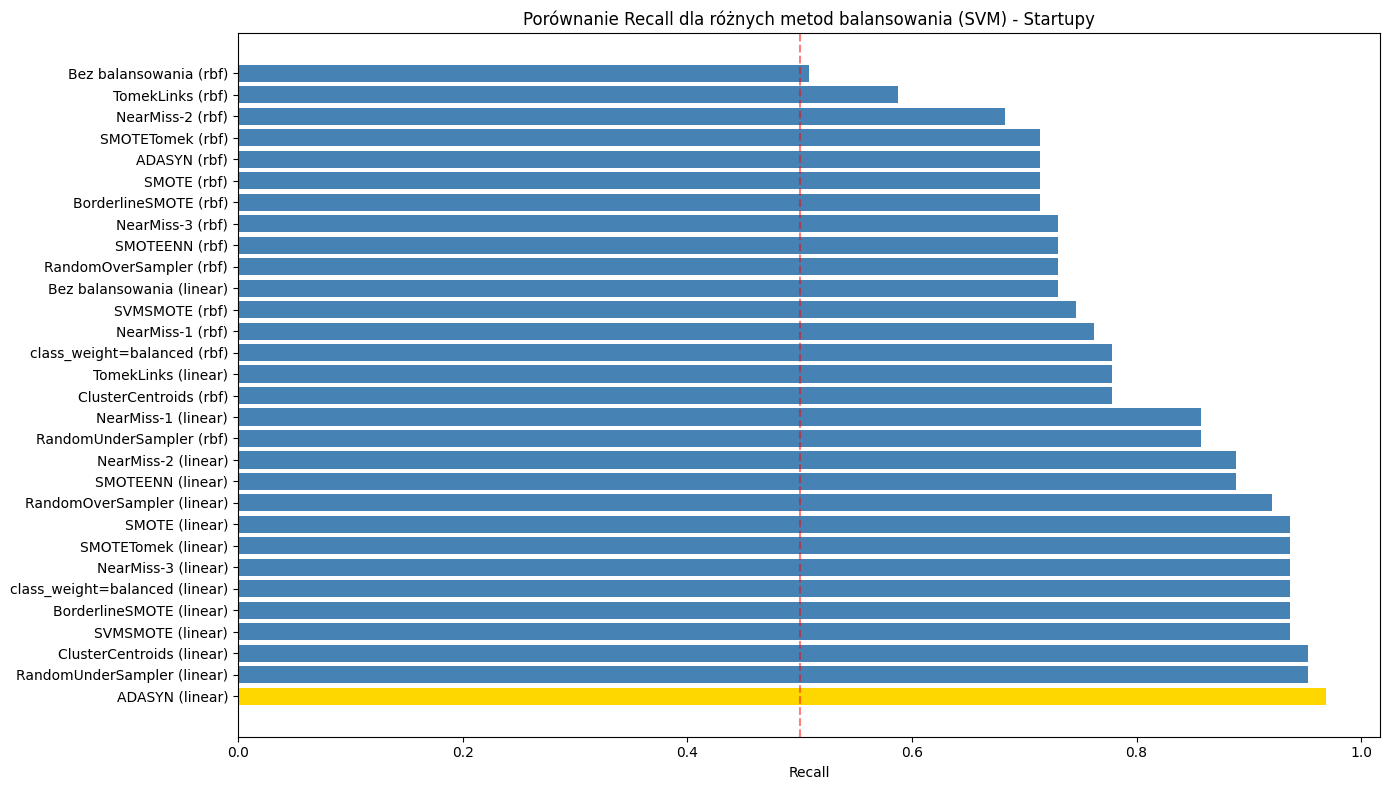


Najlepszy model: ADASYN (linear) (Recall = 0.9683)


In [249]:
plt.figure(figsize=(14, 8))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df['Metoda'], results_df['Recall'], color=colors)
plt.xlabel('Recall')
plt.title('Porównanie Recall dla różnych metod balansowania (SVM) - Startupy')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_method = results_df.iloc[0]['Metoda']
best_recall = results_df.iloc[0]['Recall']
print(f'\nNajlepszy model: {best_method} (Recall = {best_recall:.4f})')

## Najlepszy model - szczegółowa analiza

Nasz najlepszy model według recall ma tez bardzo dobre accuracy, wiec nie musimy zmieniać naszego wyboru

## Predykcja na zbiorze testowym

In [251]:
final_df = startup_proc.copy()

# Wyrównanie kolumn z treningiem
test_features = X.columns.tolist()
X_pred = final_df.reindex(columns=test_features, fill_value=0)
X_pred_scaled = scaler.transform(X_pred)

print('Przygotowane dane testowe:', X_pred_scaled.shape)

Przygotowane dane testowe: (300, 71)


In [252]:
# Predykcja
pred_encoded = best_clf.predict(X_pred_scaled)

# Odkodowanie: 1 -> 'başarılı', 0 -> 'başarısız'
basari_pred = np.where(pred_encoded == 1, 'başarılı', 'başarısız')

print(f'Rozkład predykcji: {pd.Series(basari_pred).value_counts().to_dict()}')

Rozkład predykcji: {'başarısız': 224, 'başarılı': 76}


In [254]:
# Zapis do pliku s.csv
s_csv = pd.DataFrame({'basari_durumu': basari_pred})
s_csv.to_csv('s.csv', index=False)
print('Zapisano plik s.csv')

Zapisano plik s.csv
